# Center-of-uncertainty interval unfolding (`unfold_interval_center`)

This notebook applies the center-of-uncertainty method (Askerkin &
Sukhanov) to the IAEA Compendium benchmark spectrum. See:

> В. А. Аскеркин, А. Л. Суханов. О центре неопределённости решения
> линейных интервальных задач. Дiffeом. уравнения, 1988.

The method first computes guaranteed componentwise bounds on the
spectrum (2n LPs). When the readings are *incompatible* (the
information set is empty), it solves a second LP that minimises a
weighted total widening of the data intervals — a quantitative
measure of incompatibility (`epsilon` per reading,
`incompatibility` overall) — and rebuilds bounds from the repaired
intervals.

In [1]:
# %pip install bssunfold pandas numpy matplotlib

## 1. Detector response functions

We use the built-in GSF response functions (10 Bonner spheres, `0in` -
`18in`, 60 energy bins from 1e-9 to ~631 MeV).

Detector grid: 60 bins, 1.0e-09 - 631.0 MeV
Spheres: 0in, 2in, 3in, 5in, 6in, 8in, 10in, 12in, 15in, 18in


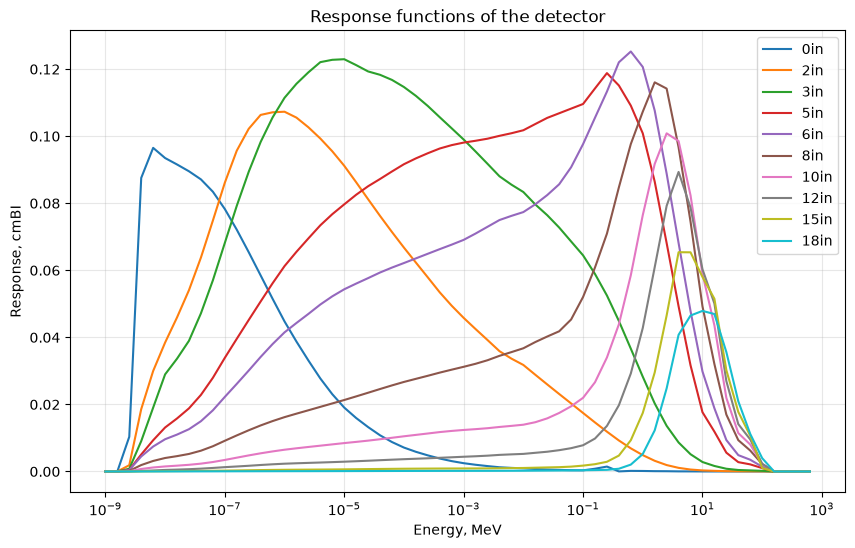

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from bssunfold import Detector, RF_GSF
from bssunfold.utils.comparison import compare_spectra

detector = Detector(RF_GSF)
E = detector.E_MeV
names = detector.detector_names
print(f"Detector grid: {detector.n_energy_bins} bins, "
      f"{E[0]:.1e} - {E[-1]:.1f} MeV")
print("Spheres:", ", ".join(names))
detector.plot_response_functions()

## 2. IAEA Compendium reference spectrum -> detector readings

The compendium CSV stores 61-point Monte-Carlo spectra on its own energy
grid, which differs slightly from the 60-bin detector grid, so the
ground truth is interpolated onto the detector grid *for evaluation
only*.  The readings are the spectrum folded with the response
functions.

In [3]:
reference_csv = pd.read_csv(
    '../tests/MonteCarlo_Calculated_spectra_from_IAEA_Comp_for_comparison.csv'
)
print(f"Reference CSV: {len(reference_csv)} rows, "
      f"{len(reference_csv.columns) - 1} spectra, "
      f"{reference_csv['E_MeV'].min():.1e} - "
      f"{reference_csv['E_MeV'].max():.0f} MeV")

SPECTRUM = 't4-14-s.txt_1'   # IAEA Compendium BSA benchmark case

readings = detector.get_effective_readings_for_spectra(
    reference_csv[['E_MeV', SPECTRUM]]
)
print("Effective readings:")
for name, val in readings.items():
    print(f"  {name:>4s}: {val:.4f}")

# Interpolate ground truth onto detector grid for evaluation
phi_true = np.interp(
    E, reference_csv['E_MeV'], reference_csv[SPECTRUM]
)

# Active energy bins for plotting
Emax = 20.0
active = E <= Emax
E_active = E[active]
phi_true_active = phi_true[active]

Reference CSV: 61 rows, 20 spectra, 1.0e-09 - 631 MeV
Effective readings:
   0in: 0.0668
   2in: 0.0901
   3in: 0.1382
   5in: 0.1639
   6in: 0.1407
   8in: 0.0805
  10in: 0.0392
  12in: 0.0179
  15in: 0.0064
  18in: 0.0031


## 3. Compatible data: center bounds and midpoint

With `noise_level=0.05` the IAEA readings are compatible, so
`incompatibility = 0` and no widening is needed. The output provides
`spectrum_lower`/`spectrum_upper` (componentwise hull of the
information set) and `spectrum` (its center of uncertainty).

In [4]:
result = detector.unfold_interval_center(
    readings,
    noise_level=0.05,
    max_neutron_energy=20.0,
    save_result=False,
)
print("method          :", result["method"])
print("converged       :", result["converged"])
print("incompatibility :", result["incompatibility"])
width = np.sum(result["spectrum_upper"] - result["spectrum_lower"])
print(f"total width     : {width:.4f}")
m = compare_spectra(phi_true, result["spectrum"],
                    metrics=["comprehensive_score"])
print(f"score (center)  : {m['comprehensive_score']:.3f}")

method          : IntervalCenter
converged       : True
incompatibility : 0.0
total width     : 46.4517
score (center)  : 9.381


## 4. Forcing incompatibility: a corrupted reading

The IAEA readings are folded from a spectrum in the model's own range,
so they stay compatible even for tiny noise levels. To exercise the
repair mechanism we corrupt one channel instead: the `5in` reading is
inflated by 20% while all corridors stay at 5%. The information set
becomes empty, and the widening LP reports *where* the data must give
way — `epsilon` is largest exactly at the corrupted channel, and the
scalar `incompatibility` quantifies how far the dataset is from
consistency. The repaired intervals still yield usable bounds.

In [5]:
bad = dict(readings)
bad["5in"] = 1.2 * bad["5in"]

tight = detector.unfold_interval_center(
    bad,
    noise_level=0.05,
    max_neutron_energy=20.0,
    save_result=False,
)
print("incompatibility :", f"{tight['incompatibility']:.6f}")
eps = np.asarray(tight["epsilon"])
order = np.argsort(-eps)
print("per-reading epsilon (largest first):")
for i in order[:3]:
    print(f"  {names[i]:>4s}: {eps[i]:.6f}")
print("worst channel flagged correctly:", names[int(order[0])] == "5in")

incompatibility : 0.004517
per-reading epsilon (largest first):
   5in: 0.004517
   0in: 0.000000
   2in: 0.000000
worst channel flagged correctly: True


## 5. Noise sweep and TV regularisation

The first axis sweeps the measurement uncertainty; the total bound
width must grow monotonically. The second applies a total-variation
budget $\sum_i |x_{i+1} - x_i| \le T$. Note the effect on the
*first* bin (E = 1e-9 MeV): its response is vanishingly small, so
without TV its upper bound is effectively unbounded (the LP reports
no finite optimum and the package conservatively records a zero-width
entry). The TV budget couples the bin to its neighbours and makes the
whole hull finite — regularization here *rescues* the bound rather
than merely tightening it.

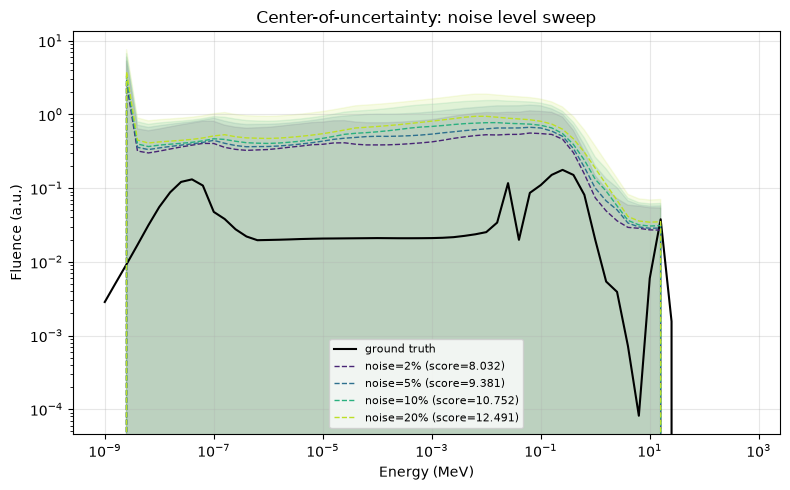

width without TV : 46.4517  (bin 0 unbounded -> recorded as 0)
width with TV=20 : 86.2840  (bin 0 now finite: upper = 19.92)


In [6]:
noise_levels = [0.02, 0.05, 0.10, 0.20]

fig, ax = plt.subplots(figsize=(8, 5))
ax.loglog(E, phi_true, "k-", lw=1.5, label="ground truth")
colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(noise_levels)))
for color, nl in zip(colors, noise_levels):
    res = detector.unfold_interval_center(
        readings, noise_level=nl, max_neutron_energy=20.0,
        save_result=False,
    )
    score = compare_spectra(phi_true, res["spectrum"],
                            metrics=["comprehensive_score"])
    ax.loglog(E, res["spectrum"], "--", color=color, lw=1,
              label=f"noise={nl:.0%} (score={score['comprehensive_score']:.3f})")
    ax.fill_between(E, res["spectrum_lower"], res["spectrum_upper"],
                    color=color, alpha=0.12)

ax.set_xlabel("Energy (MeV)")
ax.set_ylabel("Fluence (a.u.)")
ax.set_title("Center-of-uncertainty: noise level sweep")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

res_tv = detector.unfold_interval_center(
    readings, noise_level=0.05, tv_bound=20.0,
    max_neutron_energy=20.0, save_result=False,
)
w_free = np.sum(result["spectrum_upper"] - result["spectrum_lower"])
w_tv = np.sum(res_tv["spectrum_upper"] - res_tv["spectrum_lower"])
print(f"width without TV : {w_free:.4f}  (bin 0 unbounded -> recorded as 0)")
print(f"width with TV=20 : {w_tv:.4f}  (bin 0 now finite: "
      f"upper = {res_tv['spectrum_upper'][0]:.2f})")

## 6. Dose-rate bounds

Because the dose conversion coefficients are non-negative, every
dose-rate functional is linear in the spectrum and its guaranteed
bounds follow directly from the componentwise spectrum bounds:
`doserates_lower` / `doserates_upper` for each ICRP-116 curve.

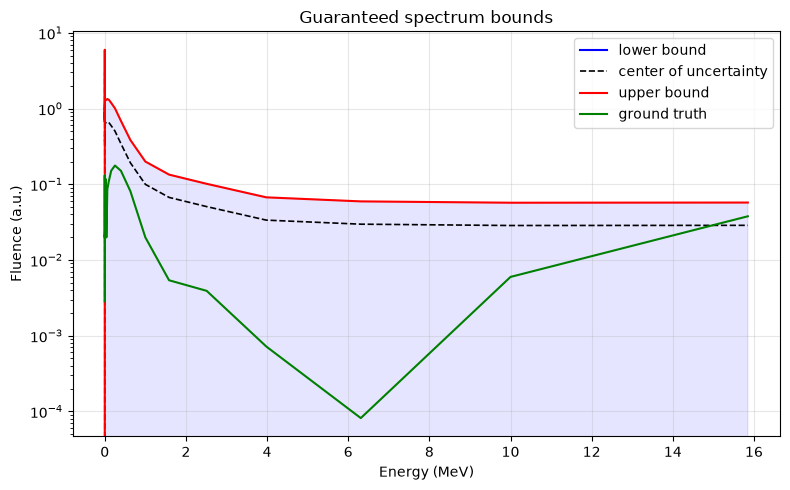

curve            dose      lower      upper
--------------------------------------------
AP           231.5014     0.0000   463.0029
PA           141.7603     0.0000   283.5207
LLAT          89.6696     0.0000   179.3392
RLAT          77.4583     0.0000   154.9166
ROT          139.7100     0.0000   279.4201
ISO          109.1637     0.0000   218.3273


In [7]:
fig, ax = plt.subplots(figsize=(8, 5))
lo_a = result["spectrum_lower"][active]
mid_a = result["spectrum"][active]
hi_a = result["spectrum_upper"][active]
ax.semilogy(E_active, lo_a, "b-", label="lower bound")
ax.semilogy(E_active, mid_a, "k--", lw=1.2,
            label="center of uncertainty")
ax.semilogy(E_active, hi_a, "r-", label="upper bound")
ax.semilogy(E_active, phi_true_active, "g-", lw=1.5, label="ground truth")
ax.fill_between(E_active, lo_a, hi_a, color="blue", alpha=0.1)
ax.set_xlabel("Energy (MeV)")
ax.set_ylabel("Fluence (a.u.)")
ax.set_title("Guaranteed spectrum bounds")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"{'curve':<10s} {'dose':>10s} {'lower':>10s} {'upper':>10s}")
print("-" * 44)
for i, name in enumerate(result["doserates"].keys()):
    print(f"{name:<10s} {result['doserates'][name]:>10.4f} "
          f"{result['doserates_lower'][name]:>10.4f} "
          f"{result['doserates_upper'][name]:>10.4f}")

## 7. Baselines

The center estimate is compared with **GRAVEL** and **MLEM**,
run from the same flat prior.

In [8]:
grav = detector.unfold_gravel(
    readings,
    initial_spectrum=np.full(E.size, 0.5),
    max_iterations=2000,
    save_result=False,
)
mlem = detector.unfold_mlem(
    readings,
    initial_spectrum=np.full(E.size, 0.5),
    max_iterations=2000,
    save_result=False,
)
print(f"{'method':<24s} {'score':>8s}")
print("-" * 34)
for label, spec in [
    ("Interval center", result["spectrum"]),
    ("GRAVEL", grav["spectrum"]),
    ("MLEM", mlem["spectrum"]),
]:
    m = compare_spectra(phi_true, spec, metrics=["comprehensive_score"])
    print(f"{label:<24s} {m['comprehensive_score']:>8.3f}")

method                      score
----------------------------------
Interval center             9.381
GRAVEL                      2.954
MLEM                        1.519


## 8. Summary

* `unfold_interval_center` combines the guaranteed 2n-LP bounds with
  the Askerkin-Sukhanov center of uncertainty.
* Incompatibility is *quantified*, not hidden: `epsilon` per reading
  and the scalar `incompatibility` (weighted minimum total widening
  of the corridors) appear whenever the information set is empty, and
  the bounds are computed from the repaired intervals.
* `weights` let the user mark channels whose readings should be
  trusted more (larger weight → widened last).
* TV regularisation tightens the hull; dose-rate bounds come free
  with the standard result dict.